# Patterns of protein- and metabolite-based cell-cell communication (LIANA+)

This tutorial is focused on running Tensor-cell2cell v2 purely by using the tool [LIANA+](https://liana-py.readthedocs.io/) to predict protein- and metabolite-mediated cell-cell communication (CCC), separately. LIANA+ was [previously integrated with Tensor-cell2cell](https://ccc-protocols.readthedocs.io/), so we can run everything smoothly and directly generate the tensors.

In this case, we use samples from cortical brain organoids across different time points, previously published by [Trujillo et al (2019)](https://doi.org/10.1016/j.stem.2019.08.002).

In [1]:
use_gpu = False

import tensorly as tl
if use_gpu:
    tl.set_backend('pytorch')

**Importing packages to use**

In [2]:
import cell2cell as c2c
import scanpy as sc

import liana as li
import decoupler as dc

import numpy as np
import pandas as pd

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
import warnings
warnings.filterwarnings('ignore')

**IMPORTANT: In this notebook, the version 0.8.0 of cell2cell is used. Older versions do not implement the Coupled Tensor Component Analysis (CTCA).**

## 1 - Load Data

**Specify folders where the data is located, and where the outputs will be written:**

In [4]:
import os

data_folder = './data/'
directory = os.fsencode(data_folder)

output_folder = './results/LIANA/'
os.makedirs(output_folder, exist_ok=True)

### RNA-seq data

A preprocessed version of the original paper [(Trujillo et al, 2019)](https://doi.org/10.1016/j.stem.2019.08.002) can be found [here](https://codeocean.com/capsule/9262293/tree/v1/data/preprocessed/annotated_seurat_norm_harmony_2022.h5ad)

In [5]:
rnaseq = sc.read_h5ad(data_folder + '/annotated_seurat_norm_harmony_2022.h5ad')

In [6]:
rnaseq = rnaseq.raw.to_adata()

In [7]:
rnaseq.shape

(15973, 21042)

In [8]:
rnaseq.obs.head(2)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.5,seurat_clusters,celltype,old.ident
Month-01_AAACCTGAGAATTGTG-1,Month-01,6417.0,2431,2.898551,11,11,Other,11
Month-01_AAACCTGAGCAACGGT-1,Month-01,8522.0,2464,2.663694,6,6,Progenitor,6


## 2 - Data Preprocessing

### RNA-seq for CCC

We first exclude cell types that were not used by [Trujillo et al (2019)](https://doi.org/10.1016/j.stem.2019.08.002).

In [9]:
rnaseq = rnaseq[~rnaseq.obs['celltype'].isin(['MC', 'Other'])]

To perform a basic filtering of cell types within time points based on their number of cells, we first generate a combined column:

In [10]:
rnaseq.obs['celltype_timepoint'] = rnaseq.obs['celltype'].astype(str) + '_' + rnaseq.obs['orig.ident'].astype(str)

In [11]:
cell_type_counts = rnaseq.obs['celltype_timepoint'].value_counts()
min_cells = 20
valid_cell_types = cell_type_counts[cell_type_counts >= min_cells].index
adata = rnaseq[rnaseq.obs['celltype_timepoint'].isin(valid_cell_types)]
adata.shape

(12792, 21042)

Then, we normalize the data:

In [12]:
sc.pp.normalize_total(rnaseq)
sc.pp.log1p(rnaseq)

## 3 - Infer cell-cell communication with LIANA+

In [13]:
sample_key = 'orig.ident'
groupby = 'celltype'

### Protein-mediated modality

We first use LIANA to predict CCC mediated by protein ligands and receptors, as previously done in [this tutorial](https://ccc-protocols.readthedocs.io/en/latest/notebooks/ccc_python/QuickStart_pbmc.html)

In [14]:
li.mt.rank_aggregate.by_sample(adata,
                               sample_key=sample_key,
                               groupby=groupby,
                               resource_name = 'consensus',
                               expr_prop=0.1, # must be expressed in expr_prop fraction of cells
                               min_cells = 5,
                               n_perms = 100,
                               use_raw = False, # run on log- and library-normalized counts
                               verbose = True,
                               inplace = True,
                               return_all_lrs=True, # return all LR values
                              )

Converting `orig.ident` to categorical!
Now running: Month-10: 100%|██████████████████████████████████████████████████████████| 4/4 [01:01<00:00, 15.50s/it]


Results can be found here:

In [15]:
adata.uns['liana_res'].head()

,orig.ident,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
0,Month-01,Glia,Glia,MDK,NCL,1.062089,0.00,0.966921,0.290163,0.089959,0.074526,0.925330,0.000045,1.708695e-08
1,Month-01,Progenitor,Glia,MDK,NCL,1.036312,0.00,0.932859,0.108443,0.081726,0.071901,0.924081,0.000056,6.834581e-08
2,Month-01,Glia,Progenitor,MDK,NCL,1.034963,0.00,0.887523,0.217578,0.039795,0.068406,0.922315,0.000071,2.733674e-07
3,Month-01,Glia,Glutamatergic,MDK,NCL,1.031363,0.06,0.876988,0.207946,0.034401,0.067594,0.921886,0.000076,4.271241e-07
4,Month-01,IP,Glia,MDK,NCL,1.027941,0.02,0.921797,0.049431,0.042089,0.071048,0.923662,0.000059,4.271241e-07


In [16]:
protein_ccc = adata.uns['liana_res'].copy()

### Metabolite-mediated modality

We then use LIANA to predict CCC mediated by metabolite ligands, as previously done in [this tutorial combining an univariate linear model](https://liana-py.readthedocs.io/en/latest/notebooks/sc_multi.html#metabolite-mediated-ccc-from-transcriptomics-data)

First we obtain the database that contains information to predict metabolite presence:

In [17]:
metalinks = li.resource.get_metalinks(biospecimen_location='Blood',
                                      source=['CellPhoneDB', 'Cellinker', 'scConnect', # Ligand-Receptor resources
                                              'recon', 'hmr', 'rhea', 'hmdb' # Production-Degradation resources
                                              ],
                                      types=['pd', 'lr'], # NOTE: we obtain both ligand-receptor and production-degradation sets
                                     )

Next, prepare this database:

In [18]:
resource = metalinks[metalinks['type']=='lr'].copy()
resource = resource[['metabolite', 'gene_symbol']]\
    .rename(columns={'gene_symbol':'receptor'}).drop_duplicates()
resource.head()

,metabolite,receptor
173,Oxoglutaric acid,OXGR1
351,Acetaldehyde,TRPA1
410,Calcitriol,VDR
843,ADP,P2RY1
1071,ADP,P2RY6


We split it into two parts: 1) the information that links enzymes producing or consuming each metabolite:

In [19]:
pd_net = metalinks[metalinks['type'] == 'pd']
# we need to aggregate the production-degradation values
pd_net = pd_net[['metabolite', 'gene_symbol', 'mor']].groupby(['metabolite', 'gene_symbol']).agg('mean').reset_index()
pd_net.head()

,metabolite,gene_symbol,mor
0,(+)-Limonene,CYP2C19,-1.0
1,(+)-Limonene,CYP2C9,-1.0
2,(R)-Lipoic acid,CEL,1.0
3,(R)-Lipoic acid,DLD,-1.0
4,(R)-Lipoic acid,LIPA,1.0


In [20]:
pd_net.rename(columns={'metabolite' : 'source', 'gene_symbol': 'target' , 'mor': 'weight'}, inplace=True)

And 2) the information that contains the transporter of each metabolite

In [21]:
t_net = metalinks[metalinks['type'] == 'pd']
t_net = t_net[['metabolite', 'gene_symbol', 'transport_direction']].dropna()
# Note that we treat export as positive and import as negative
t_net['mor'] = t_net['transport_direction'].apply(lambda x: 1 if x == 'out' else -1 if x == 'in' else None)
t_net = t_net[['metabolite', 'gene_symbol', 'mor']].dropna().groupby(['metabolite', 'gene_symbol']).agg('mean').reset_index()
t_net = t_net[t_net['mor']!=0]

In [22]:
t_net.rename(columns={'metabolite' : 'source', 'gene_symbol': 'target' , 'mor': 'weight'}, inplace=True)

**With this we can predict metabolite abundances**

This is ugly code due to issues with LIANA+ versions, but if you manage to have no issues you can directly call the function `li.mt.fun.estimate_metalinks()` instead, as in here:
```
meta = li.mt.fun.estimate_metalinks(adata,
                                    resource,
                                    pd_net=pd_net,
                                    t_net=t_net, # (Optional)
                                    use_raw=False, 
                                    # keyword arguments passed to decoupler-py
                                    source='metabolite', target='gene_symbol',
                                    weight='mor', min_n=3)
# pass cell type information
meta.obs['celltype'] = adata.obs['celltype']
```

In [23]:
from mudata import MuData

In [24]:
dc.mt.ulm(adata, net=pd_net, raw=False)
met_est = adata.obsm['score_ulm']

In [25]:
dc.mt.waggr(adata, t_net, times=0, raw=False, fun='wmean')

out_est = adata.obsm['score_waggr']
intersect = np.intersect1d(met_est.columns, out_est.columns)
out_est = out_est[intersect]
out_mask = out_est > 0
mask = np.ones(out_est.shape)
mask[out_mask == 0] = 0
# mask those with transporters
mmat = met_est[intersect] * mask
# concat the rest
coldiff = np.setdiff1d(met_est.columns, mmat.columns)
mmat = pd.concat([mmat, met_est[coldiff]], axis = 1)

In [26]:
_resource = resource[resource['metabolite'].isin(mmat.columns)].copy()
receptor = adata[:, adata.var.index.isin(np.unique(_resource['receptor']))]

In [27]:
adata.obsm['mmat'] = mmat
mmat = li.utils.obsm_to_adata(adata, 'mmat')
meta = MuData({'metabolite':mmat, 'receptor':receptor})

This is where the ugly code ends

In [28]:
# pass cell type information
meta.obs[groupby] = adata.obs[groupby]
meta.obs[sample_key] = adata.obs[sample_key]

... storing 'celltype' as categorical
... storing 'celltype_timepoint' as categorical


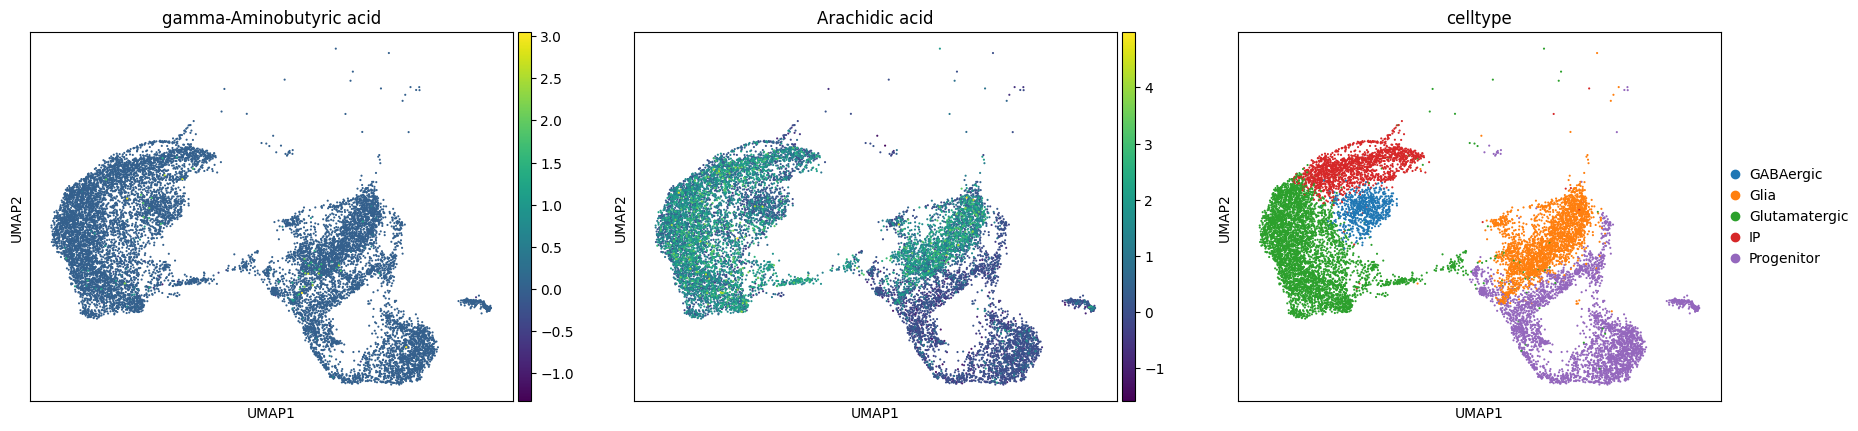

In [29]:
sc.pl.umap(meta.mod['metabolite'], color=['gamma-Aminobutyric acid', 'Arachidic acid', 'celltype'])

**Finally compute cell-cell communication**

In [30]:
li.mt.rank_aggregate.by_sample(meta,
                               sample_key=sample_key,
                               groupby=groupby,
                               use_raw=False,
                               # pass our modified resource
                               resource=resource.rename(columns={'metabolite':'ligand'}),
                               # NOTE: Essential arguments when handling multimodal data
                               mdata_kwargs={
                               'x_mod': 'metabolite',
                               'y_mod': 'receptor',
                               'x_use_raw':False,
                               'y_use_raw':False,
                               'x_transform':li.ut.zi_minmax,
                               'y_transform':li.ut.zi_minmax,
                              },
                               expr_prop=0.1, # must be expressed in expr_prop fraction of cells
                               min_cells = 5,
                               n_perms = 100,
                            verbose=True
                            )

Now running: Month-10: 100%|██████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.40s/it]


And the results:

In [31]:
meta.uns['liana_res'].head()

,orig.ident,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
0,Month-01,Glia,Progenitor,Sphinganine,TRPM3,0.359097,0.00,0.124714,0.092563,0.210764,0.165734,0.715372,0.027473,0.000129
1,Month-01,Progenitor,Progenitor,Sphinganine,TRPM3,0.351860,0.00,0.118574,0.069406,0.227814,0.157574,0.710204,0.039417,0.000514
2,Month-01,Progenitor,Progenitor,Sodium,TRPM3,0.319108,0.00,0.090789,0.068954,0.226059,0.160477,0.681978,0.035748,0.018032
3,Month-01,Glia,Glia,Sphinganine,TRPM3,0.317264,0.79,0.100116,-0.030954,-0.017828,0.133044,0.692487,1.000000,0.027954
4,Month-01,Glia,Glutamatergic,all-trans-Retinoic acid,RARB,0.017623,0.93,0.000182,-0.081092,-0.020941,0.021961,0.087561,1.000000,0.033962


In [32]:
met_ccc = meta.uns['liana_res'].copy()

## 4 - Generate Tensors

We first sort our contexts:

In [33]:
contexts = sorted(adata.obs[sample_key].unique())
contexts

['Month-01', 'Month-03', 'Month-06', 'Month-10']

### 4D communication tensors

LIANA and Tensor-cell2cell are conveniently interconnected, so generating tensors from LIANA is quite smooth.
We start with the protein-based tensor:

In [34]:
tensor_prot = li.multi.to_tensor_c2c(liana_res=protein_ccc, # LIANA's dataframe containing results
                                     sample_key=sample_key, # Column name of the samples
                                     source_key='source', # Column name of the sender cells
                                     target_key='target', # Column name of the receiver cells
                                     ligand_key='ligand_complex', # Column name of the ligands
                                     receptor_key='receptor_complex', # Column name of the receptors
                                     score_key='magnitude_rank', # Column name of the communication scores to use
                                     inverse_fun=lambda x: 1 - x, # Transformation function
                                     how='outer_cells', # What to include across all samples
                                     outer_fraction=1/3, # Fraction of samples as threshold to include cells and LR pairs.
                                     context_order=contexts, # Order to store the contexts in the tensor
                                     order_labels=['Contexts', 'Protein LRIs', 'Sender Cells', 'Receiver Cells']
                                    )

100%|█████████████████████████████████████████████████████████████████████████████████| 4/4 [00:33<00:00,  8.32s/it]


In [35]:
tensor_prot.shape

(4, 1303, 5, 5)

Then, we continue with the metabolite-based tensor

In [36]:
tensor_met = li.multi.to_tensor_c2c(liana_res=met_ccc, # LIANA's dataframe containing results
                                     sample_key=sample_key, # Column name of the samples
                                     source_key='source', # Column name of the sender cells
                                     target_key='target', # Column name of the receiver cells
                                     ligand_key='ligand_complex', # Column name of the ligands
                                     receptor_key='receptor_complex', # Column name of the receptors
                                     score_key='magnitude_rank', # Column name of the communication scores to use
                                     inverse_fun=lambda x: 1 - x, # Transformation function
                                     how='outer_cells', # What to include across all samples
                                     outer_fraction=1/3., # Fraction of samples as threshold to include cells and LR pairs.
                                     context_order=contexts, # Order to store the contexts in the tensor
                                     order_labels=['Contexts', 'Metabolite LRIs', 'Sender Cells', 'Receiver Cells']
                                    )

100%|█████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 31.67it/s]


In [37]:
tensor_met.shape

(4, 8, 5, 5)

### Generate coupled tensors

Once we have our 4D tensors, we start creating a `CoupledInteractionTensor`object in Tensor-cell2cell v2. This object will later perform the CTCA.

In [38]:
coupled_tensor = c2c.tensor.CoupledInteractionTensor(tensor1=tensor_prot,
                                                     tensor2=tensor_met,
                                                     tensor1_name='cell2cell',
                                                     tensor2_name='LIANA',
                                                     mode_mapping={'shared' : [(0,0), (2,2), (3,3)]}
                                                    )

We can observe that this object includes both tensors simultaneously.

In [39]:
coupled_tensor.shape

((4, 1303, 5, 5), (4, 8, 5, 5))

## 5 - Run Analysis

### Perform tensor factorization

Next, we apply a non-negative canonical coupled component analysis (CTCA). Briefly, tensor decomposition identifies a low-rank tensor (here, a rank of 6) for each modality's tensor that better approximates each original tensor. These low-rank tensors can be represented as the sum of a set of rank-1 tensors (6 of them in this case). Each rank-1 tensor represents a factor in the decomposition and can be further represented as the outer product of n vectors, where n represents the number of tensor dimensions. Each vector represents one of the n tensor dimensions for that factor and its values, corresponding to individual elements in each dimension, represent the factor loadings. 

In the CTCA, we have vectors that are shared between the coupled tensors (here contexts, sender cells, and receiver cells), while we have other vectors that are private for each modality (protein-based LR pair and metabolite-based LR pair dimensions). The loadings shared between both tensors behave exactly the same in both modalities, representing that we are capturing LR pairs of each modality that present similar trends in each factor. If each tensor was decomposed separately with the standard TCA in Tensor-cell2cell v1, we would not ensure that the key LR pairs for each factor would behave the same, as this could lead to loadings for the context, sender cells and receiver cells with different behaviors between modalities.

![tensor-fact](../figures/CTCA.png)

To illustrate how performing the CTCA for identifying protein LR pairs acting coordinated with metabolite LR pairs, we skipped the Elbow Analysis, which can be found in our [previous tutorial using MEBOCOST](../Tensor-cell2cell-CTCA/). Instead, we run the factorization using a manual number of 6 factors:

In [40]:
coupled_tensor.compute_tensor_factorization(rank=6, # This is just for illustrative purposes - to keep a low number of factors
                                            init='svd',
                                            random_state=888,
                                            runs=1, tol=1e-8, n_iter_max=500 # Robust version of tensor decomposition
                                           )

## 6 - Results

### Metadata

**Generate a list containing metadata for each tensor order/dimension - Later used for coloring factor plots**

This is a list containing metadata for each dimension of the tensor (contexts, LR pairs, sender cells, receiver cells). Each metadata corresponds to a dataframe with info of each element in the respective dimension.

We start with the protein-based tensor.

In [41]:
prot_functions = {k: 'Proteins' for k in tensor_prot.order_names[1]}

In [42]:
meta_tf = c2c.tensor.generate_tensor_metadata(interaction_tensor=tensor_prot,
                                              metadata_dicts=[None, prot_functions, None, None],
                                              fill_with_order_elements=True
                                             )

We continue with the metabolite-based tensor.

In [43]:
met_functions = {k: 'Metabolites' for k in tensor_met.order_names[1]}

In [44]:
meta_tf2 = c2c.tensor.generate_tensor_metadata(interaction_tensor=tensor_met,
                                              metadata_dicts=[None, met_functions, None, None],
                                              fill_with_order_elements=True
                                             )

**Generate unified metadata for CTCA results**

By using the metadata generated separately for each tensor, we generate a new metadata that incorporates metadata for the shared and private dimensions between both modalities.

In [45]:
new_meta_tf = coupled_tensor.reorder_metadata(meta_tf, meta_tf2)

### Plot factor loadings

After performing the CTCA, a set of loadings is obtained in a factor-specific way, for each tensor. These loadings provide details of what elements of each dimension are important within each factor. Here we plot first the loadings for the shared dimensions, followed by the private dimensions of the first and second tesnor (protein- and metabolite-based, respectively).

In [46]:
# Color palettes for each of the coupled tensor dimensions, ordered as in order_sorting below
cmaps = ['viridis', 'tab20', 'tab20', 'Dark2', 'Dark2', ]

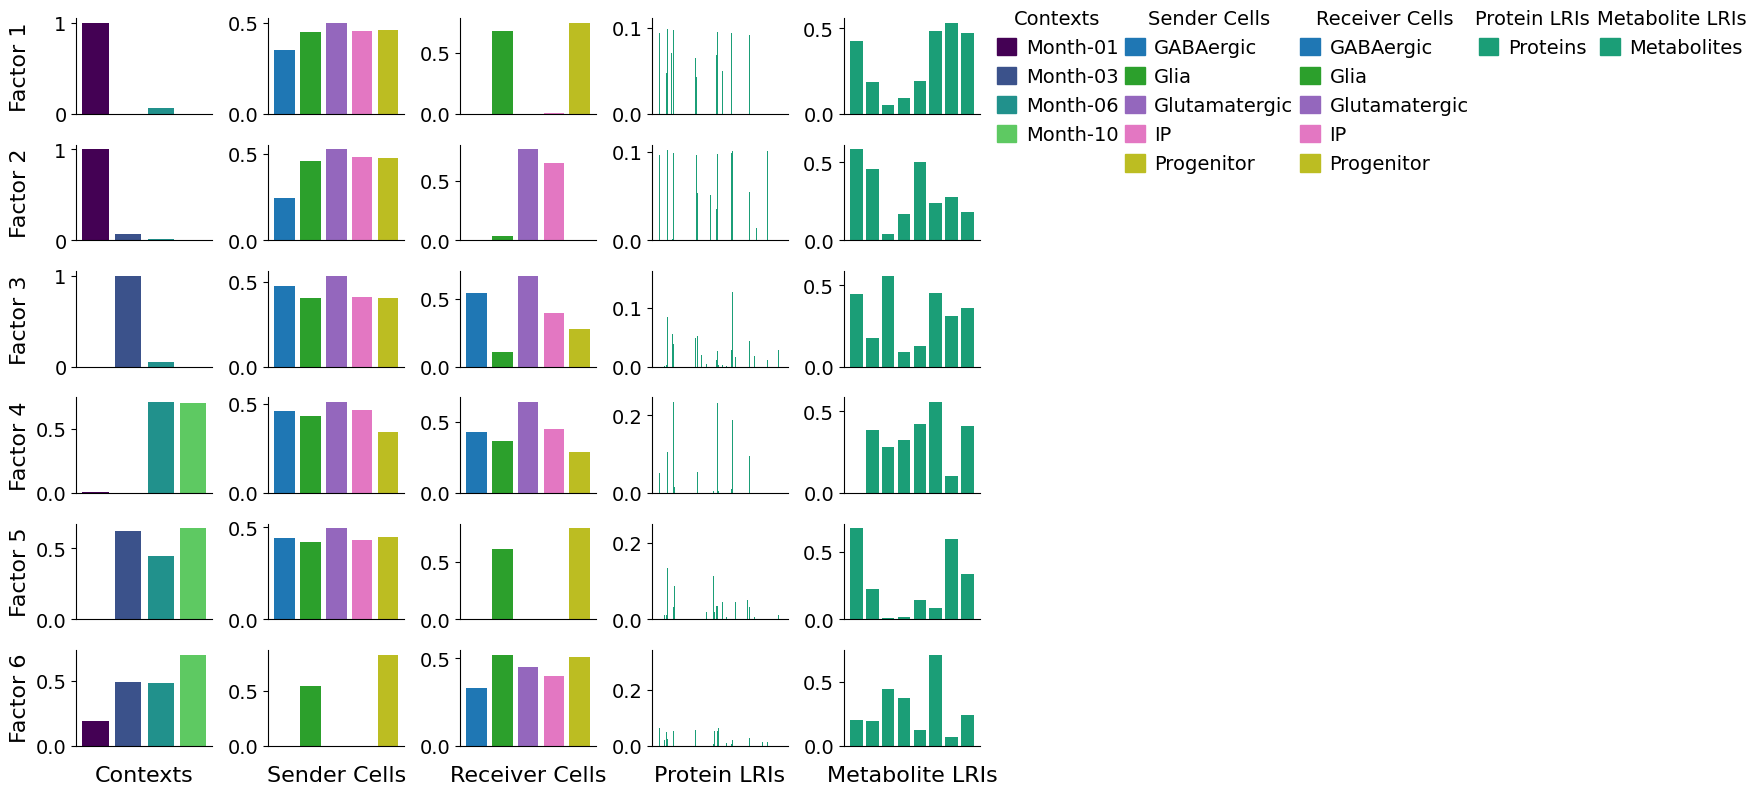

In [47]:
factors, axes = c2c.plotting.tensor_factors_plot(interaction_tensor=coupled_tensor,
                                                 metadata=new_meta_tf,
                                                 sample_col='Element',
                                                 group_col='Category',
                                                 meta_cmaps=cmaps,
                                                 order_sorting=['Contexts', 'Sender Cells', 'Receiver Cells', # Shared dimensions
                                                                'Protein LRIs', 'Metabolite LRIs' # Private dimensions
                                                               ],
                                                 fontsize=14,
                                                 filename=output_folder + 'Tensor-Factorization.pdf'
                                                )

Each factor represents a context-dependent communication pattern. In this visualization, each row is a factor and each column is a tensor dimension in that factor (Shared dimensions: contexts, sender-cells, and receiver-cells; Private dimensions: Protein LR pairs and Metabolite LR pairs). 

The loadings represent the contribution of each element to that pattern, and their combinations between all dimensions represent the overall pattern. For example, in Factors 1 and 2, the identified communication pattern occurs in early stages (month 1), where factor 1 includes glia and progenitors as the main receivers, and factor 2 includes glutamatergic neurons and intermediate progenitors (IP) as the main receivers. Then we can identify the top LR pairs contributing from each modality. Thus, those that are top ranked for the protein modality act in coordination with those top ranked for the metabolite modality.

### Top LR pairs

**Top-5 LR pairs**

In [48]:
for i in range(coupled_tensor.rank):
    print(coupled_tensor.get_top_factor_elements('Protein LRIs', 'Factor {}'.format(i+1), 5))
    print('')

MDK^ITGA6_ITGB1    0.105613
APP^NCSTN          0.103537
HMGB1^CXCR4        0.103089
MDK^NOTCH2         0.102678
APP^NOTCH2         0.102294
Name: Factor 1, dtype: float64

APP^DCC       0.102557
MDK^LRP1      0.102379
PSAP^LRP1     0.101868
GNAS^ADCY1    0.101814
CALR^LRP1     0.101737
Name: Factor 2, dtype: float64

EFNA3^EPHA4      0.153877
EFNB2^EPHA4      0.153573
PTDSS1^SCARB1    0.151579
EFNB1^EPHA4      0.148824
NCAM1^PTPRZ1     0.148381
Name: Factor 3, dtype: float64

CALM1^INSR     0.233936
CALM3^INSR     0.233691
ARF1^INSR      0.232414
HRAS^INSR      0.229986
CALM1^PTPRA    0.220818
Name: Factor 4, dtype: float64

MDK^NOTCH2     0.237271
APP^NOTCH2     0.236520
MDK^SDC2       0.212126
PTN^SDC2       0.211643
NCAM1^FGFR1    0.198114
Name: Factor 5, dtype: float64

BMP7^ACTR2        0.327814
LGALS3BP^ITGB1    0.286786
ADAM9^ITGB1       0.285304
TIMP1^CD63        0.270595
LGALS1^ITGB1      0.236729
Name: Factor 6, dtype: float64



In [49]:
for i in range(coupled_tensor.rank):
    print(coupled_tensor.get_top_factor_elements('Metabolite LRIs', 'Factor {}'.format(i+1), 5))
    print('')

Sphinganine^TRPM3                       0.530504
Sodium^TRPM3                            0.483825
Sphingosine^TRPM3                       0.471280
24-Hydroxycholesterol^NR1H2             0.423004
MG(0:0/20:4(5Z,8Z,11Z,14Z)/0:0)^CNR1    0.192030
Name: Factor 1, dtype: float64

24-Hydroxycholesterol^NR1H2             0.583786
MG(0:0/20:4(5Z,8Z,11Z,14Z)/0:0)^CNR1    0.504035
Anandamide^CNR1                         0.455289
Sphinganine^TRPM3                       0.276577
Sodium^TRPM3                            0.240267
Name: Factor 2, dtype: float64

Dopamine^HTR2C                 0.558553
Sodium^TRPM3                   0.454333
24-Hydroxycholesterol^NR1H2    0.445158
Sphingosine^TRPM3              0.360104
Sphinganine^TRPM3              0.312343
Name: Factor 3, dtype: float64

Sodium^TRPM3                            0.556499
MG(0:0/20:4(5Z,8Z,11Z,14Z)/0:0)^CNR1    0.422860
Sphingosine^TRPM3                       0.410919
Anandamide^CNR1                         0.384991
L-Glutamic acid^GR

### Export Loadings

***THESE VALUES CAN BE USED FOR DOWNSTREAM ANALYSES***

In [50]:
coupled_tensor.export_factor_loadings(output_folder + 'Coupled-Loadings.xlsx')

Coupled tensor factor loadings saved to ./results/LIANA/Coupled-Loadings.xlsx


## 7 - Downstream Analyses

### Generate factor-specific networks

We can generate factor-specific communication networks connecting sender-to-receiver cells.

In [51]:
networks = c2c.analysis.tensor_downstream.get_factor_specific_ccc_networks(coupled_tensor.factors, 
                                                                           sender_label='Sender Cells',
                                                                           receiver_label='Receiver Cells')

**Generate matrix of cell-cell pairs by factors**

In [52]:
network_by_factors = c2c.analysis.tensor_downstream.flatten_factor_ccc_networks(networks, orderby='receivers')

**Select cell-cell pairs with high potential of interaction**

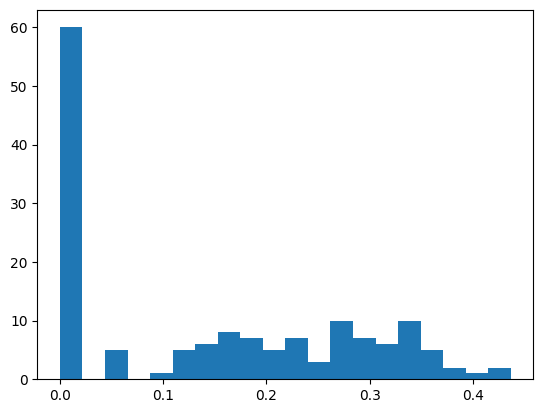

In [53]:
_ = plt.hist(network_by_factors.values.flatten(), bins = 20)

In [54]:
# To consider only cell pairs with high potential to interact in each factor
cci_threshold = 0.2

**Visualize networks of factors with significant differences between groups**

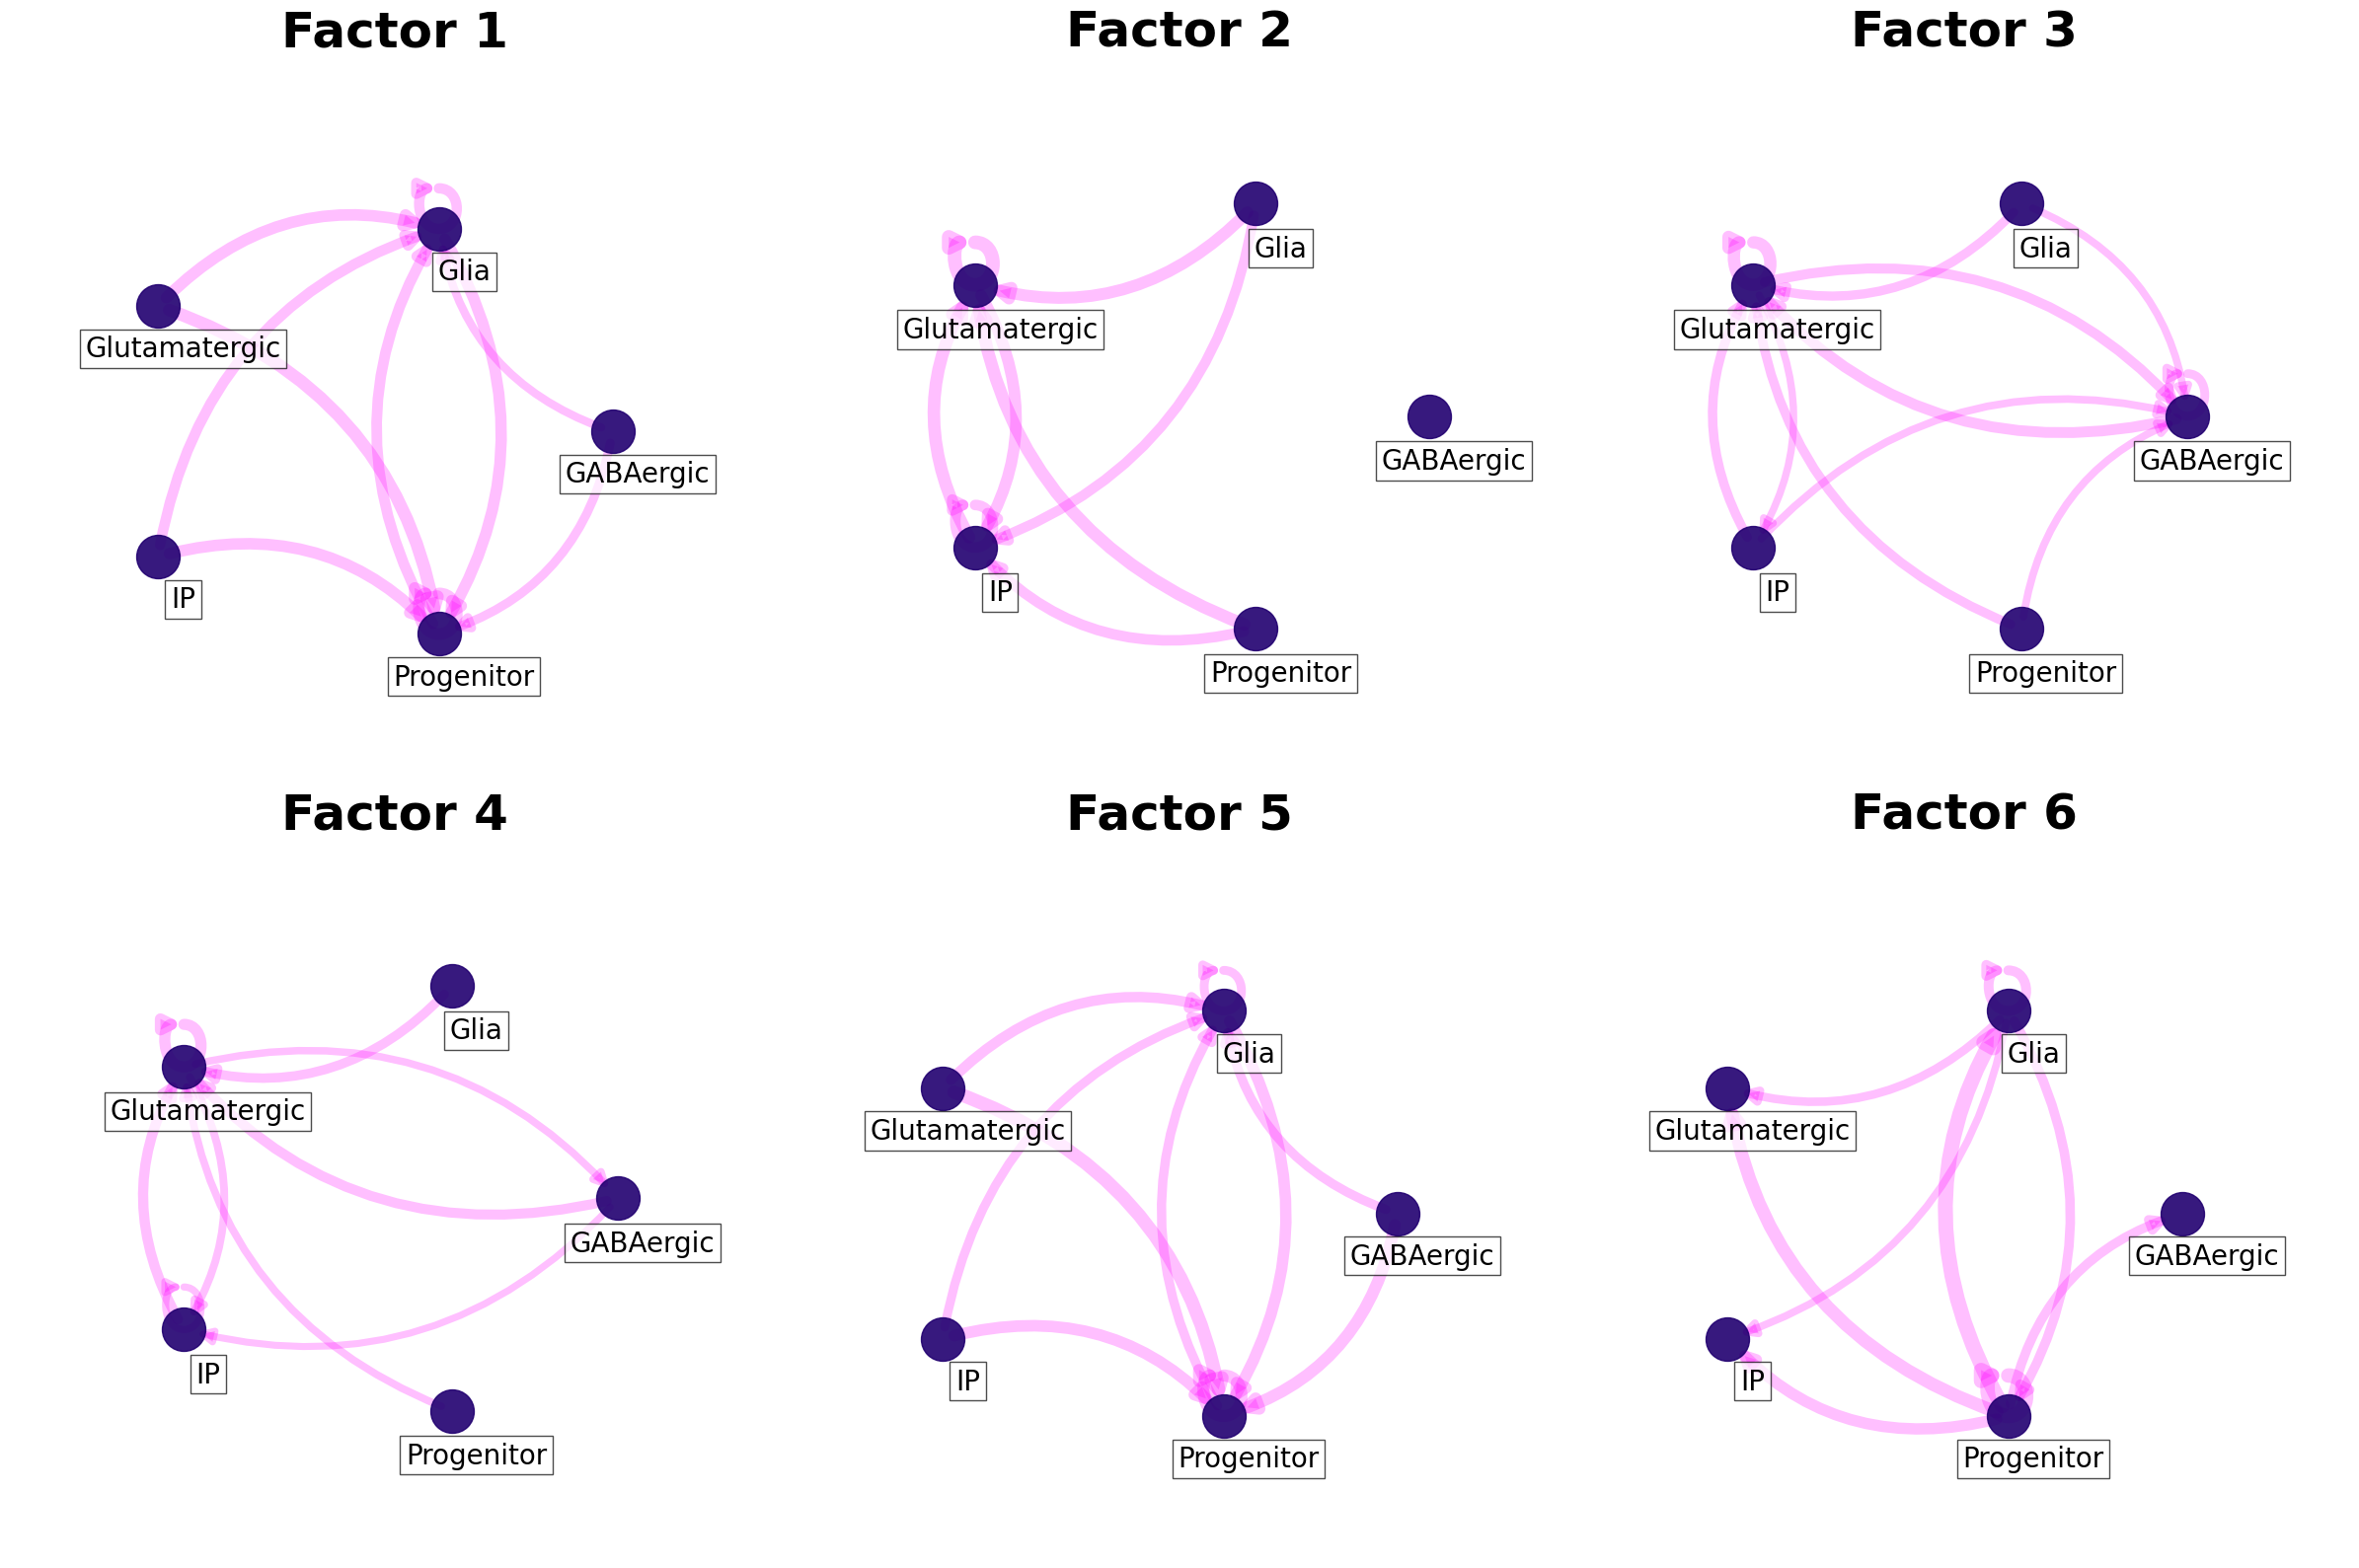

In [55]:
net_fig, net_ax = c2c.plotting.ccc_networks_plot(coupled_tensor.factors,
                                                 included_factors=None,
                                                 ccc_threshold=cci_threshold, # Only important communication
                                                 nrows=2,
                                                 panel_size=(8, 8),
                                                 network_layout='circular',
                                                 filename=output_folder + 'Networks.svg'
                                                )

### Clustermaps


Similarly, we can visualize the contribution of each dimension element across factors by plotting their loadings

In [56]:
factor_sorted = ['Factor {}'.format(f) for f in range(1, coupled_tensor.rank+1)]

**Cluster cell-cell pairs by their potential across factors**

Here we display the outer product between the sender and receiver cell dimensions, which are the value governing the factor-specific networks above.

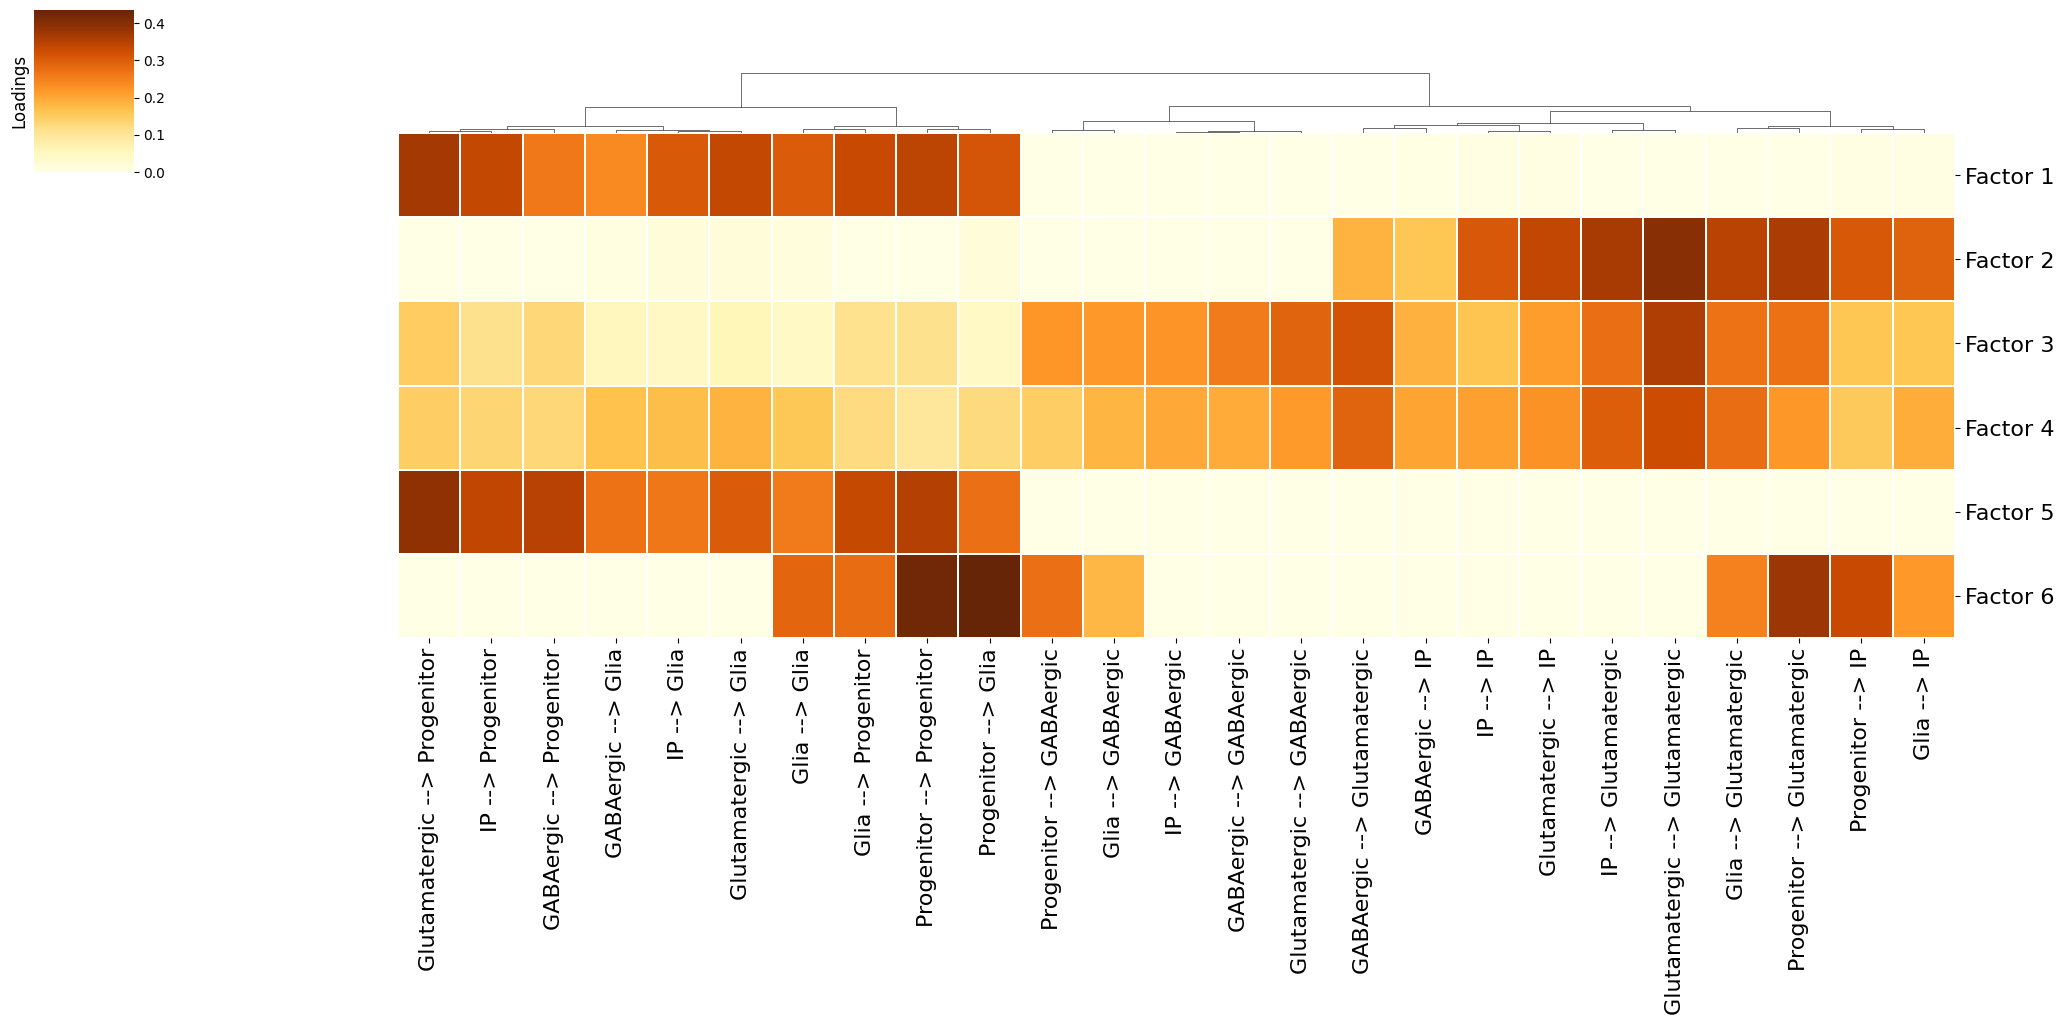

In [57]:
cci_cm = c2c.plotting.loading_clustermap(network_by_factors[factor_sorted],
                                         use_zscore=False, 
                                         loading_threshold=cci_threshold, # To consider relevant CCIs
                                         figsize=(20, 9),
                                         tick_fontsize=16,
                                         cmap='YlOrBr',
                                         filename=output_folder + 'Clustermap-Factor-specific-CCI.pdf',
                                         row_cluster=False
                                        )

**Cluster LR pairs by their importance across factors**

We can plot the key LR pairs from each modality. First we identify what could represent a high loading given their separate distributions.

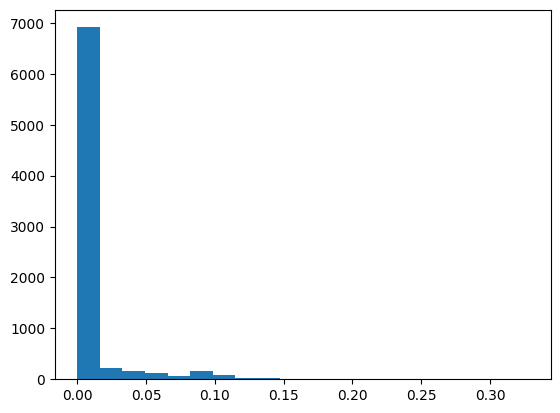

In [58]:
_ = plt.hist(coupled_tensor.factors['Protein LRIs'].values.flatten(), bins = 20)

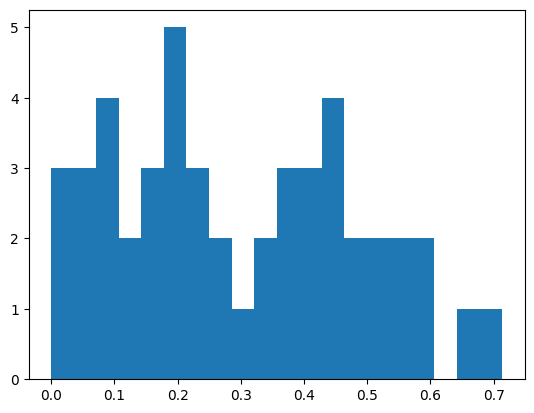

In [59]:
_ = plt.hist(coupled_tensor.factors['Metabolite LRIs'].values.flatten(), bins = 20)

And set and arbitrary threshold to filter out those that have *low loadings*

In [60]:
# To consider only most relevant LR pairs
lr_threshold1 = 0.1
lr_threshold2 = 0.5

Since we have loadings from different modalities, we want to visualize them in a comparable way, so we normalize each of them by their maximum value in each case.

In [61]:
df1 = coupled_tensor.factors['Protein LRIs'].copy()
df1 = df1[(df1.T > lr_threshold1).any()]
df1 = (df1 / df1.max())

df2 = coupled_tensor.factors['Metabolite LRIs'].copy()
df2 = df2[(df2.T > lr_threshold2).any()]
df2 = (df2 / df2.max())

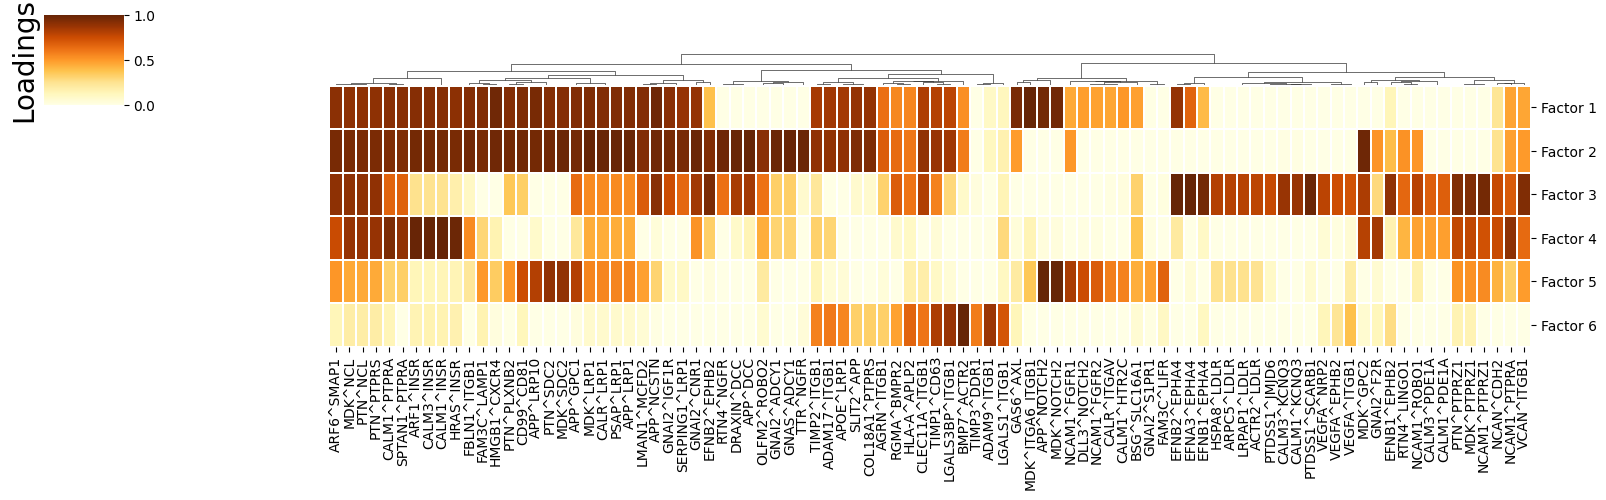

In [62]:
lr_cm = c2c.plotting.loading_clustermap(df1,
                                        loading_threshold=lr_threshold1, # To consider only top LRs
                                        use_zscore=False,
                                        figsize=(16, 5),
                                        cbar_fontsize=20,
                                        tick_fontsize=10,
                                        cmap='YlOrBr',
                                        filename=output_folder + 'Clustermap-Factor-specific-ProtLRs.pdf',
                                        row_cluster=False
                                       )

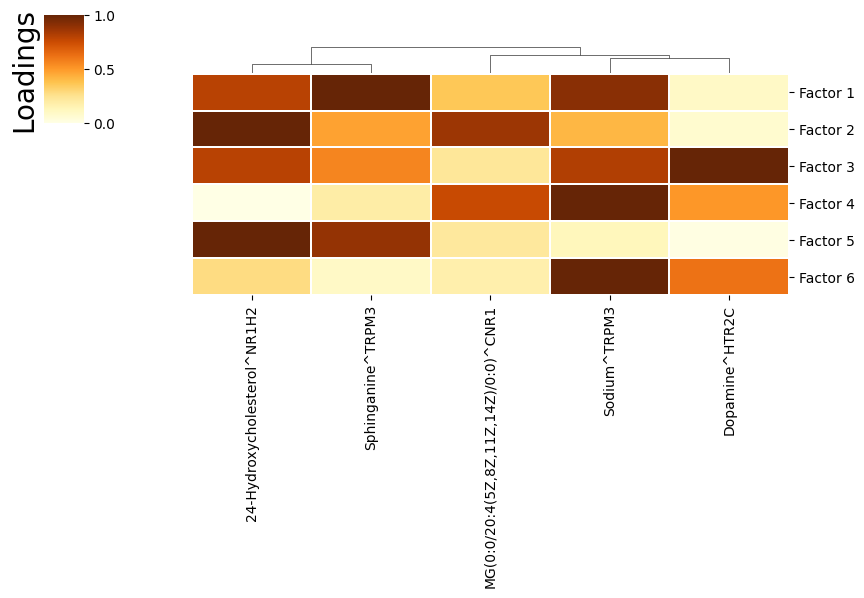

In [63]:
lr_cm = c2c.plotting.loading_clustermap(df2,
                                        loading_threshold=lr_threshold2, # To consider only top LRs
                                        use_zscore=False,
                                        figsize=(8, 6),
                                        cbar_fontsize=20,
                                        tick_fontsize=10,
                                        cmap='YlOrBr',
                                        filename=output_folder + 'Clustermap-Factor-specific-MetLRs.pdf',
                                        row_cluster=False
                                       )

Given that we max-scaled them, we can also put them together in an unified plot

In [64]:
df = pd.concat([df1, df2])

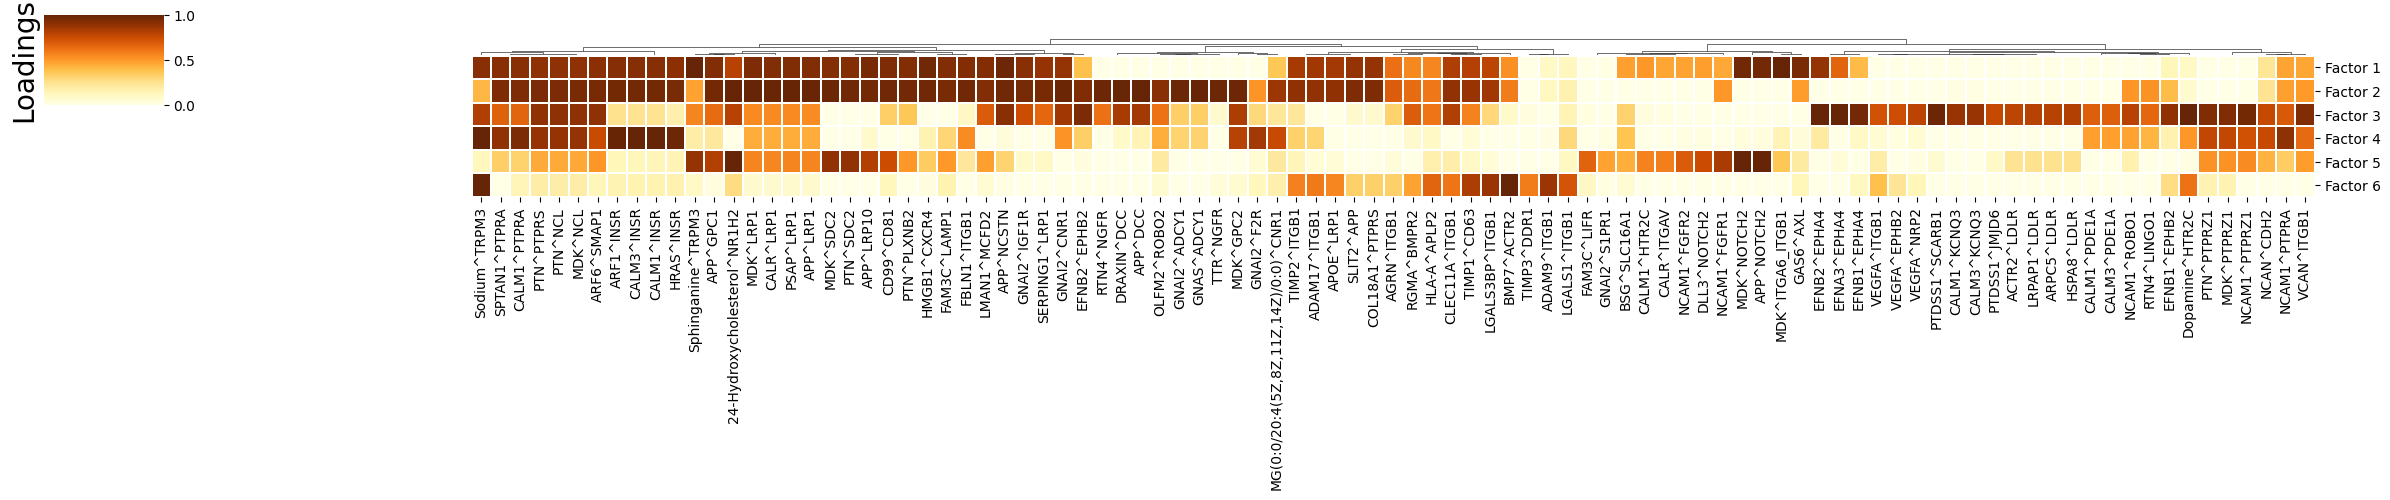

In [65]:
lr_cm = c2c.plotting.loading_clustermap(df,
                                        loading_threshold=0.15, # To consider only top LRs
                                        use_zscore=False,
                                        figsize=(24, 5),
                                        cbar_fontsize=20,
                                        tick_fontsize=10,
                                        cmap='YlOrBr',
                                        filename=output_folder + 'Clustermap-Factor-specific-LRs.pdf',
                                        row_cluster=False
                                       )